<a href="https://colab.research.google.com/github/jeanraposojesus-hue/Pratica_7_PROCSIN/blob/main/Quest%C3%A3o%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **2. Para as respostas de módulo mostrada na figura abaixo, derive a resposta ao impulso do filtro ideal. Em seguida, projete um filtro FIR de ordem M ∈ {50, 100} utilizando as janelas retangular, triangular, Hamming, Hann e Blackman. Apresente a resposta ao impulso, o diagrama de polos e zeros e a resposta em frequência dos filtros projetados. Comente os resultados obtidos.**

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz

WINDOWS = {
    'Retangular': np.ones,
    'Triangular': np.bartlett,
    'Hamming': np.hamming,
    'Hann': np.hanning,
    'Blackman': np.blackman
}

ORDERS = [50, 100]


def plot_zplane(h, ax):
    z = np.roots(h)

    theta = np.linspace(0, 2*np.pi, 500)

    ax.plot(np.cos(theta), np.sin(theta),'k--',linewidth=1)

    if len(z) > 0:
        ax.scatter(np.real(z), np.imag(z),
                   marker='o',
                   facecolors='none')

    ax.scatter([0],[0],marker='x')

    ax.set_aspect('equal')
    ax.grid(True)
    ax.set_title("Polos e Zeros")

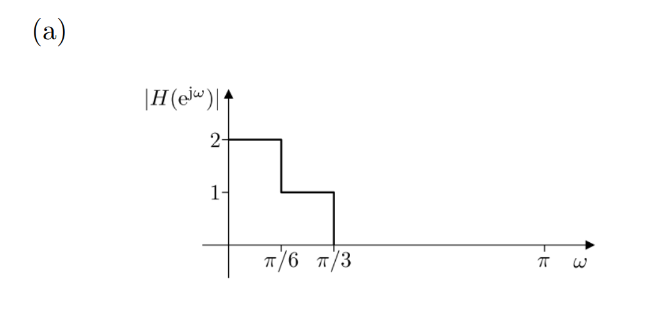

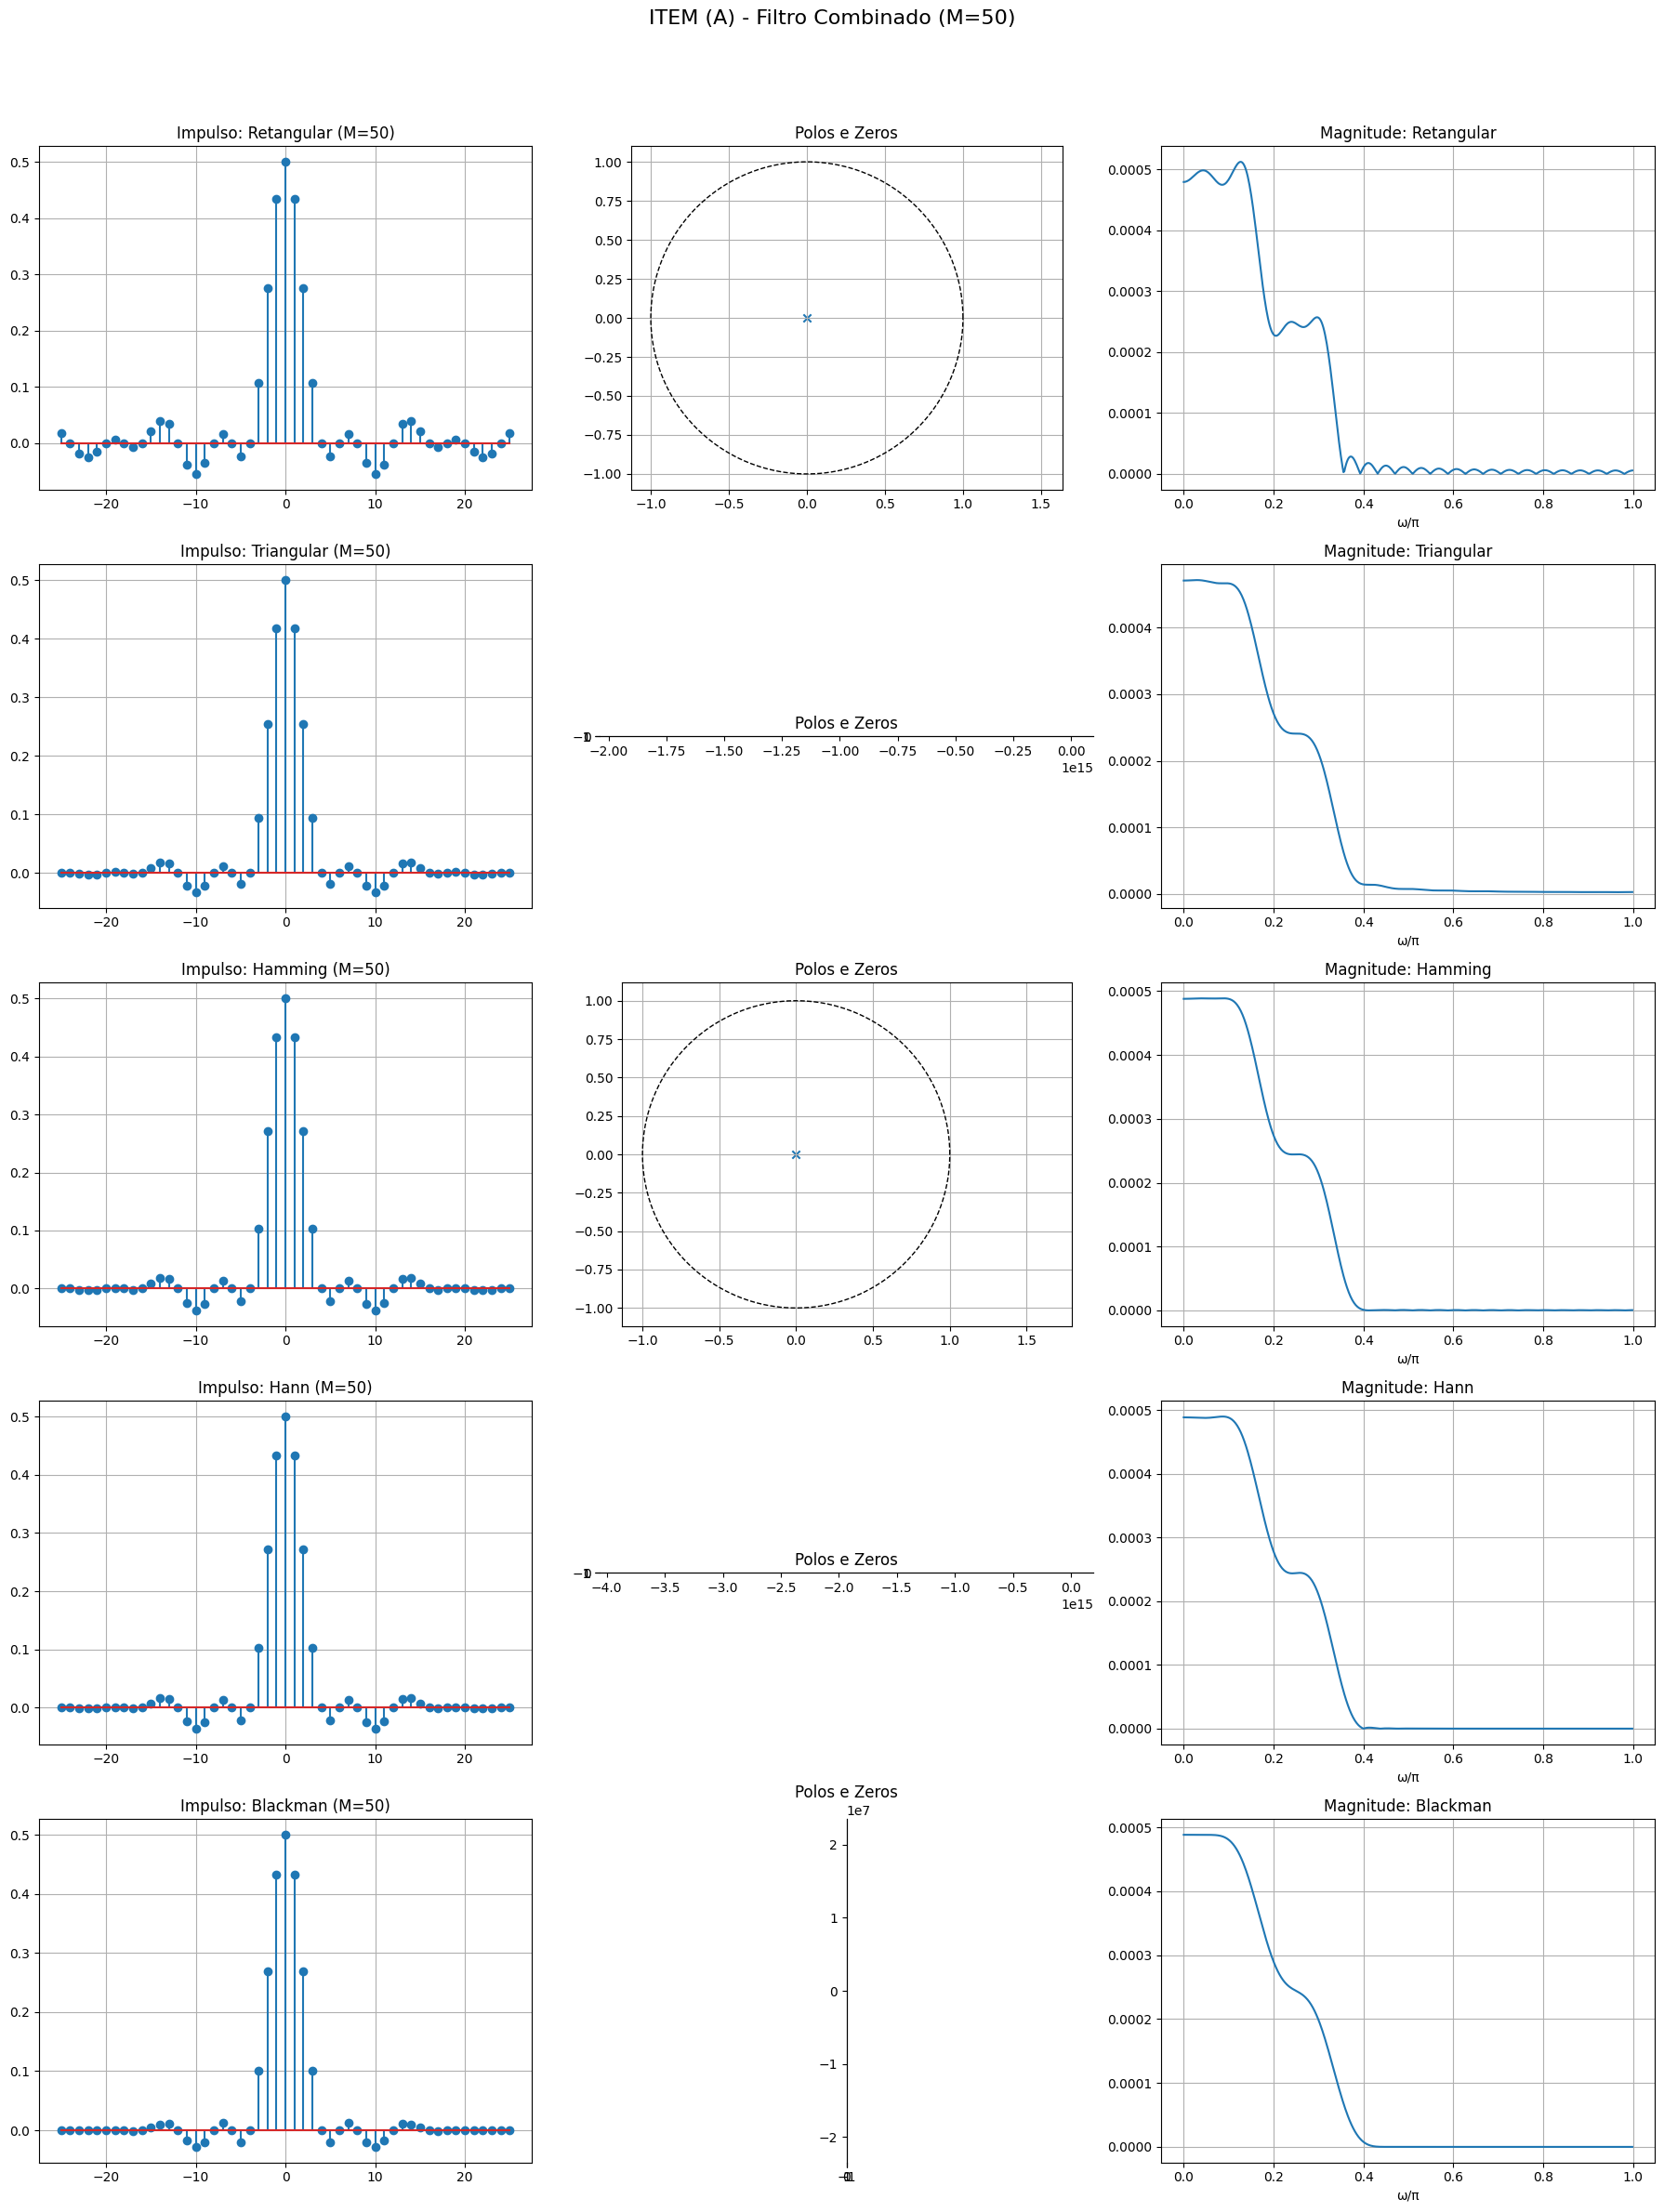

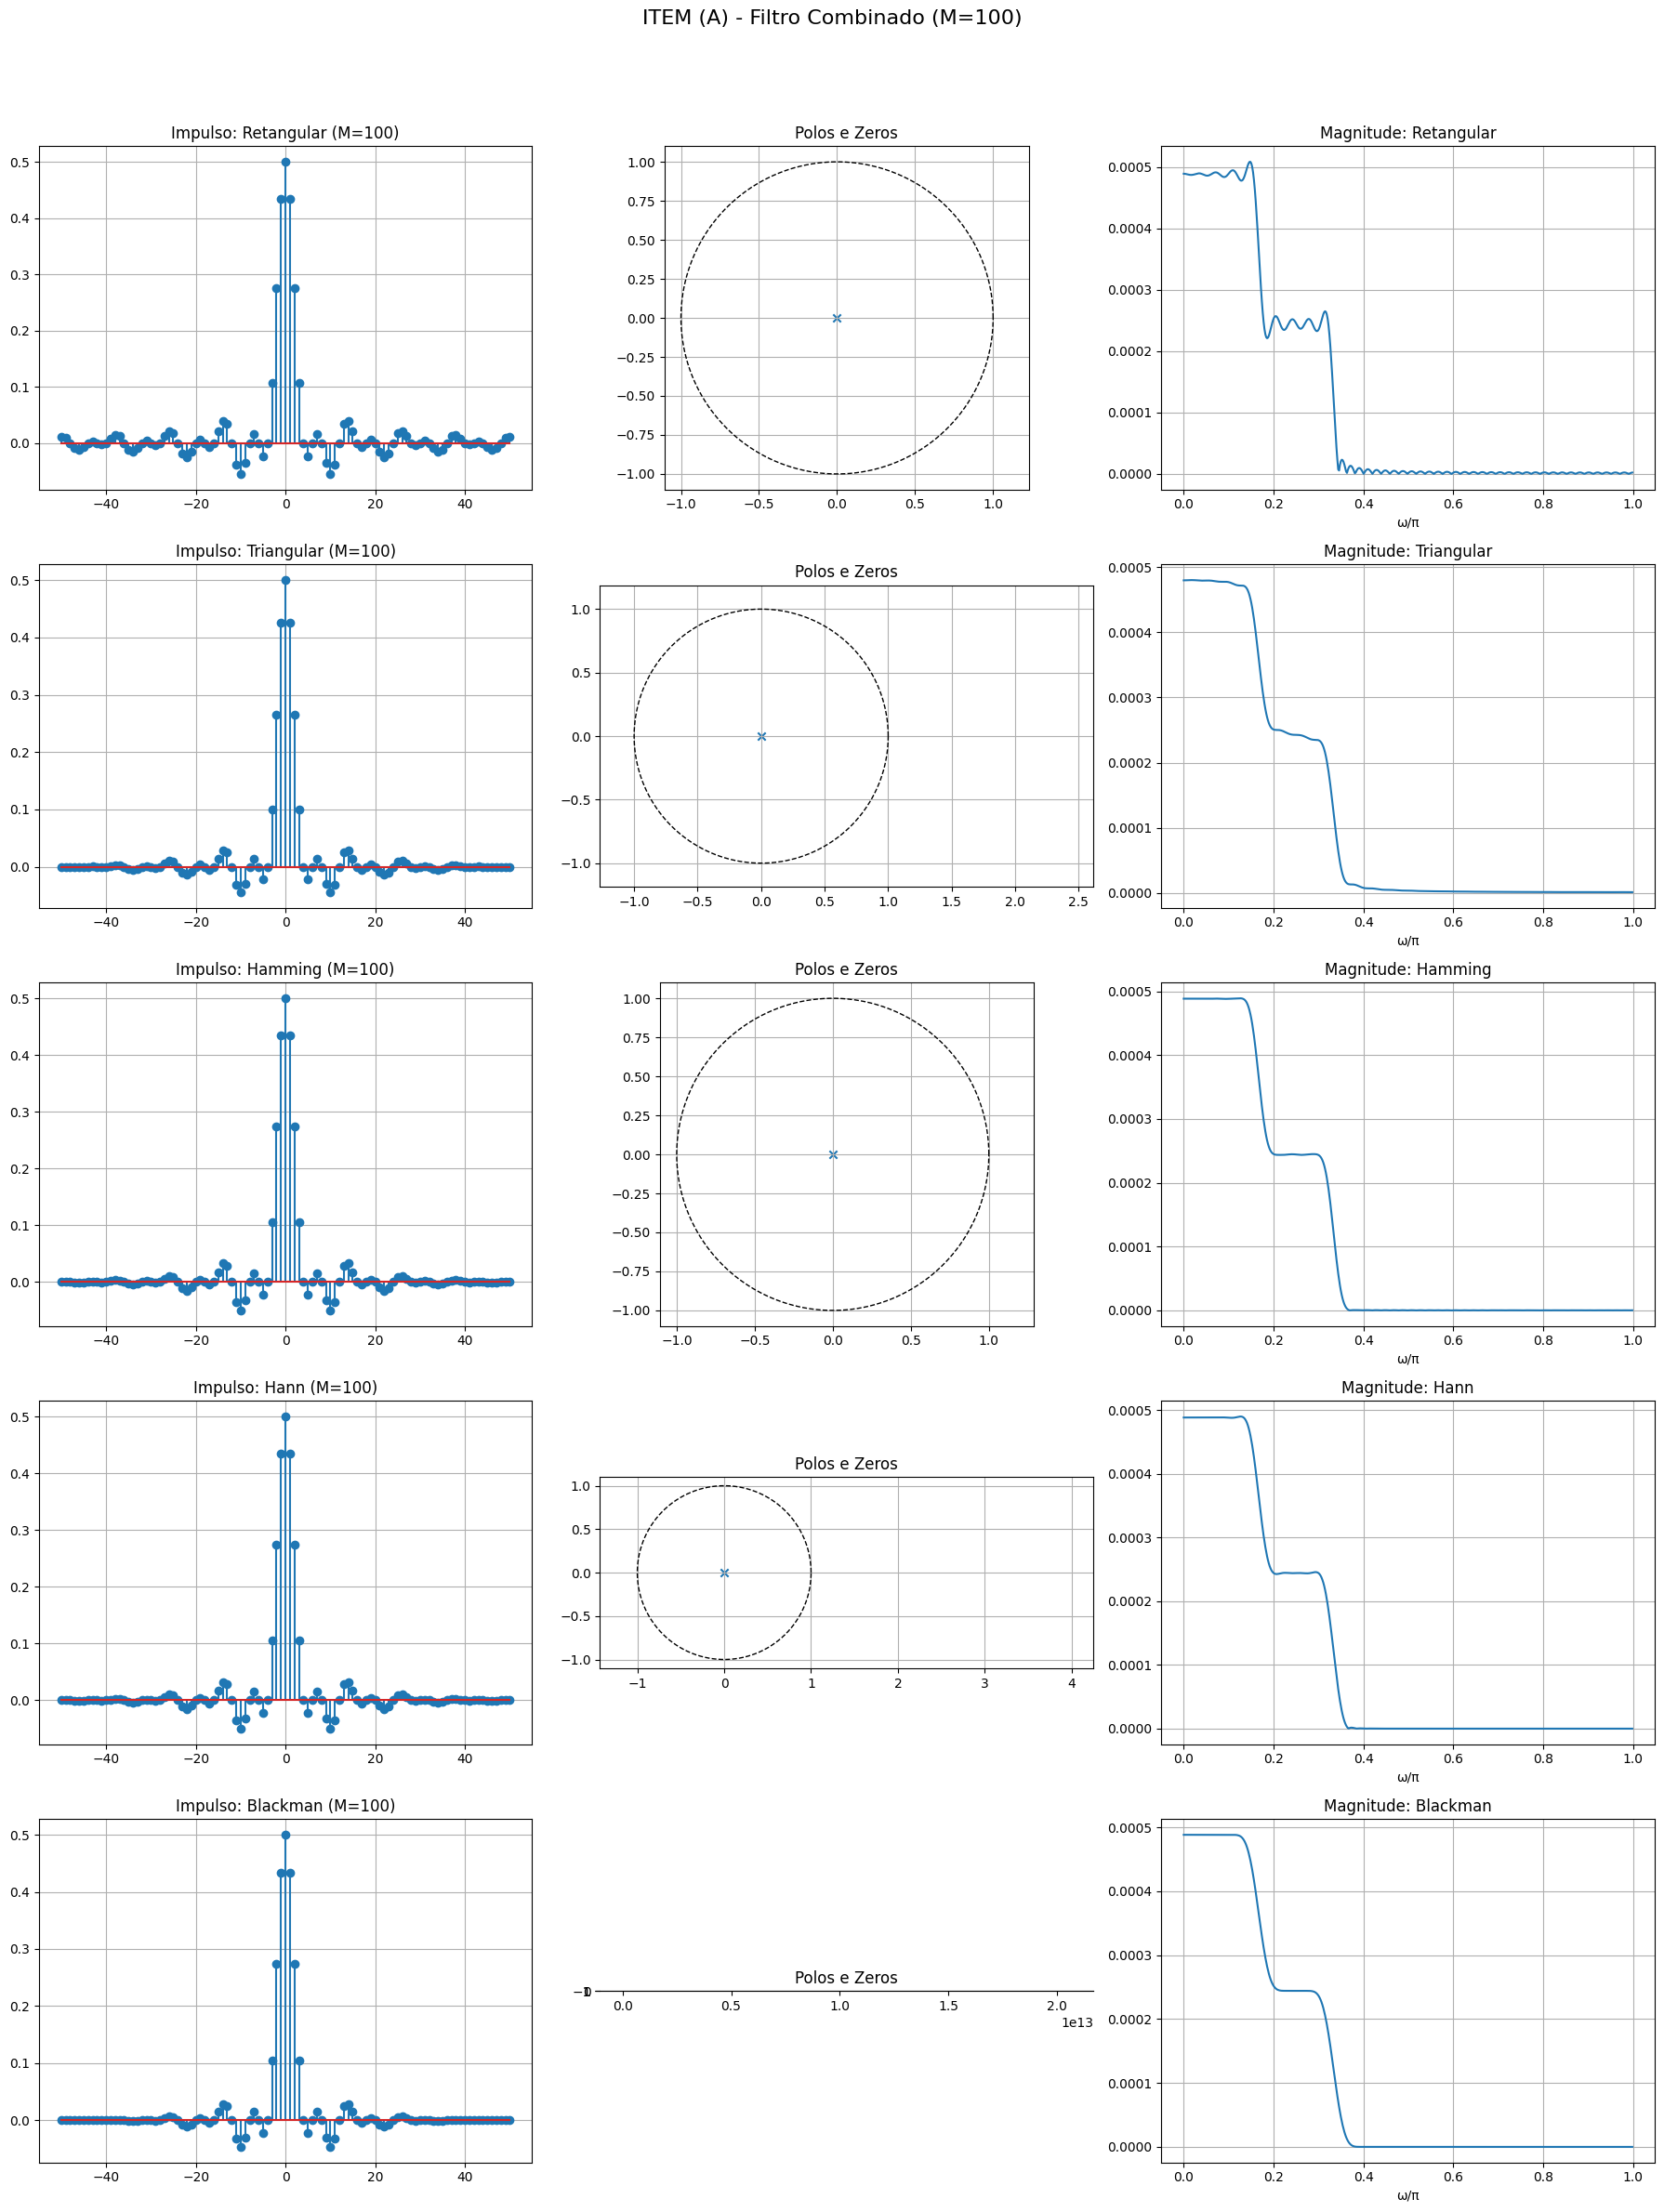

In [10]:
wc1 = np.pi/6
wc2 = np.pi/3

def hd_A(M):
    n = np.arange(-M//2, M//2 + 1)
    h = np.zeros(len(n))
    for i, ni in enumerate(n):
        if ni == 0:
            h[i] = (wc1 + wc2)/np.pi
        else:
            h[i] = (np.sin(wc1*ni) + np.sin(wc2*ni))/(np.pi*ni)
    return n, h

for M in ORDERS:
    n, hd = hd_A(M)
    windows = {name: func(len(n)) for name, func in WINDOWS.items()}

    # Plot de Resposta ao Impulso e Frequência
    fig, axs = plt.subplots(5, 3, figsize=(18, 25))
    for idx, (win_name, w) in enumerate(windows.items()):
        h = hd * w

        # Impulso
        axs[idx, 0].stem(n, h)
        axs[idx, 0].set_title(f'Impulso: {win_name} (M={M})')
        axs[idx, 0].grid(True)

        # Z-Plane
        plot_zplane(h, axs[idx, 1])

        # Frequência
        omega, H = freqz(h, 4096)
        axs[idx, 2].plot(omega/np.pi, np.abs(H))
        axs[idx, 2].set_title(f'Magnitude: {win_name}')
        axs[idx, 2].set_xlabel('ω/π')
        axs[idx, 2].grid(True)

    plt.suptitle(f'ITEM (A) - Filtro Combinado (M={M})', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

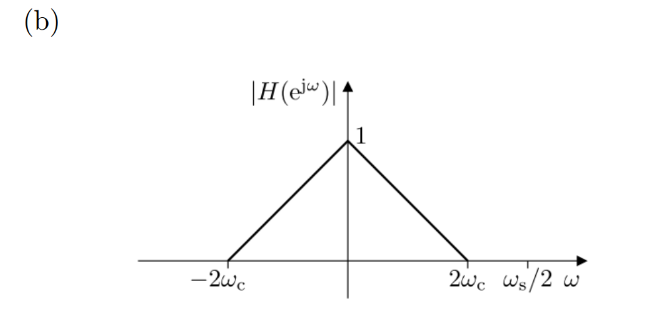

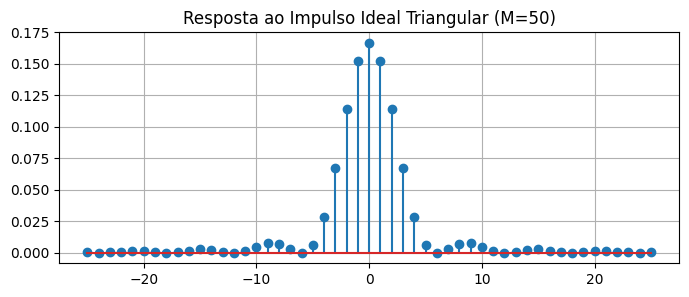

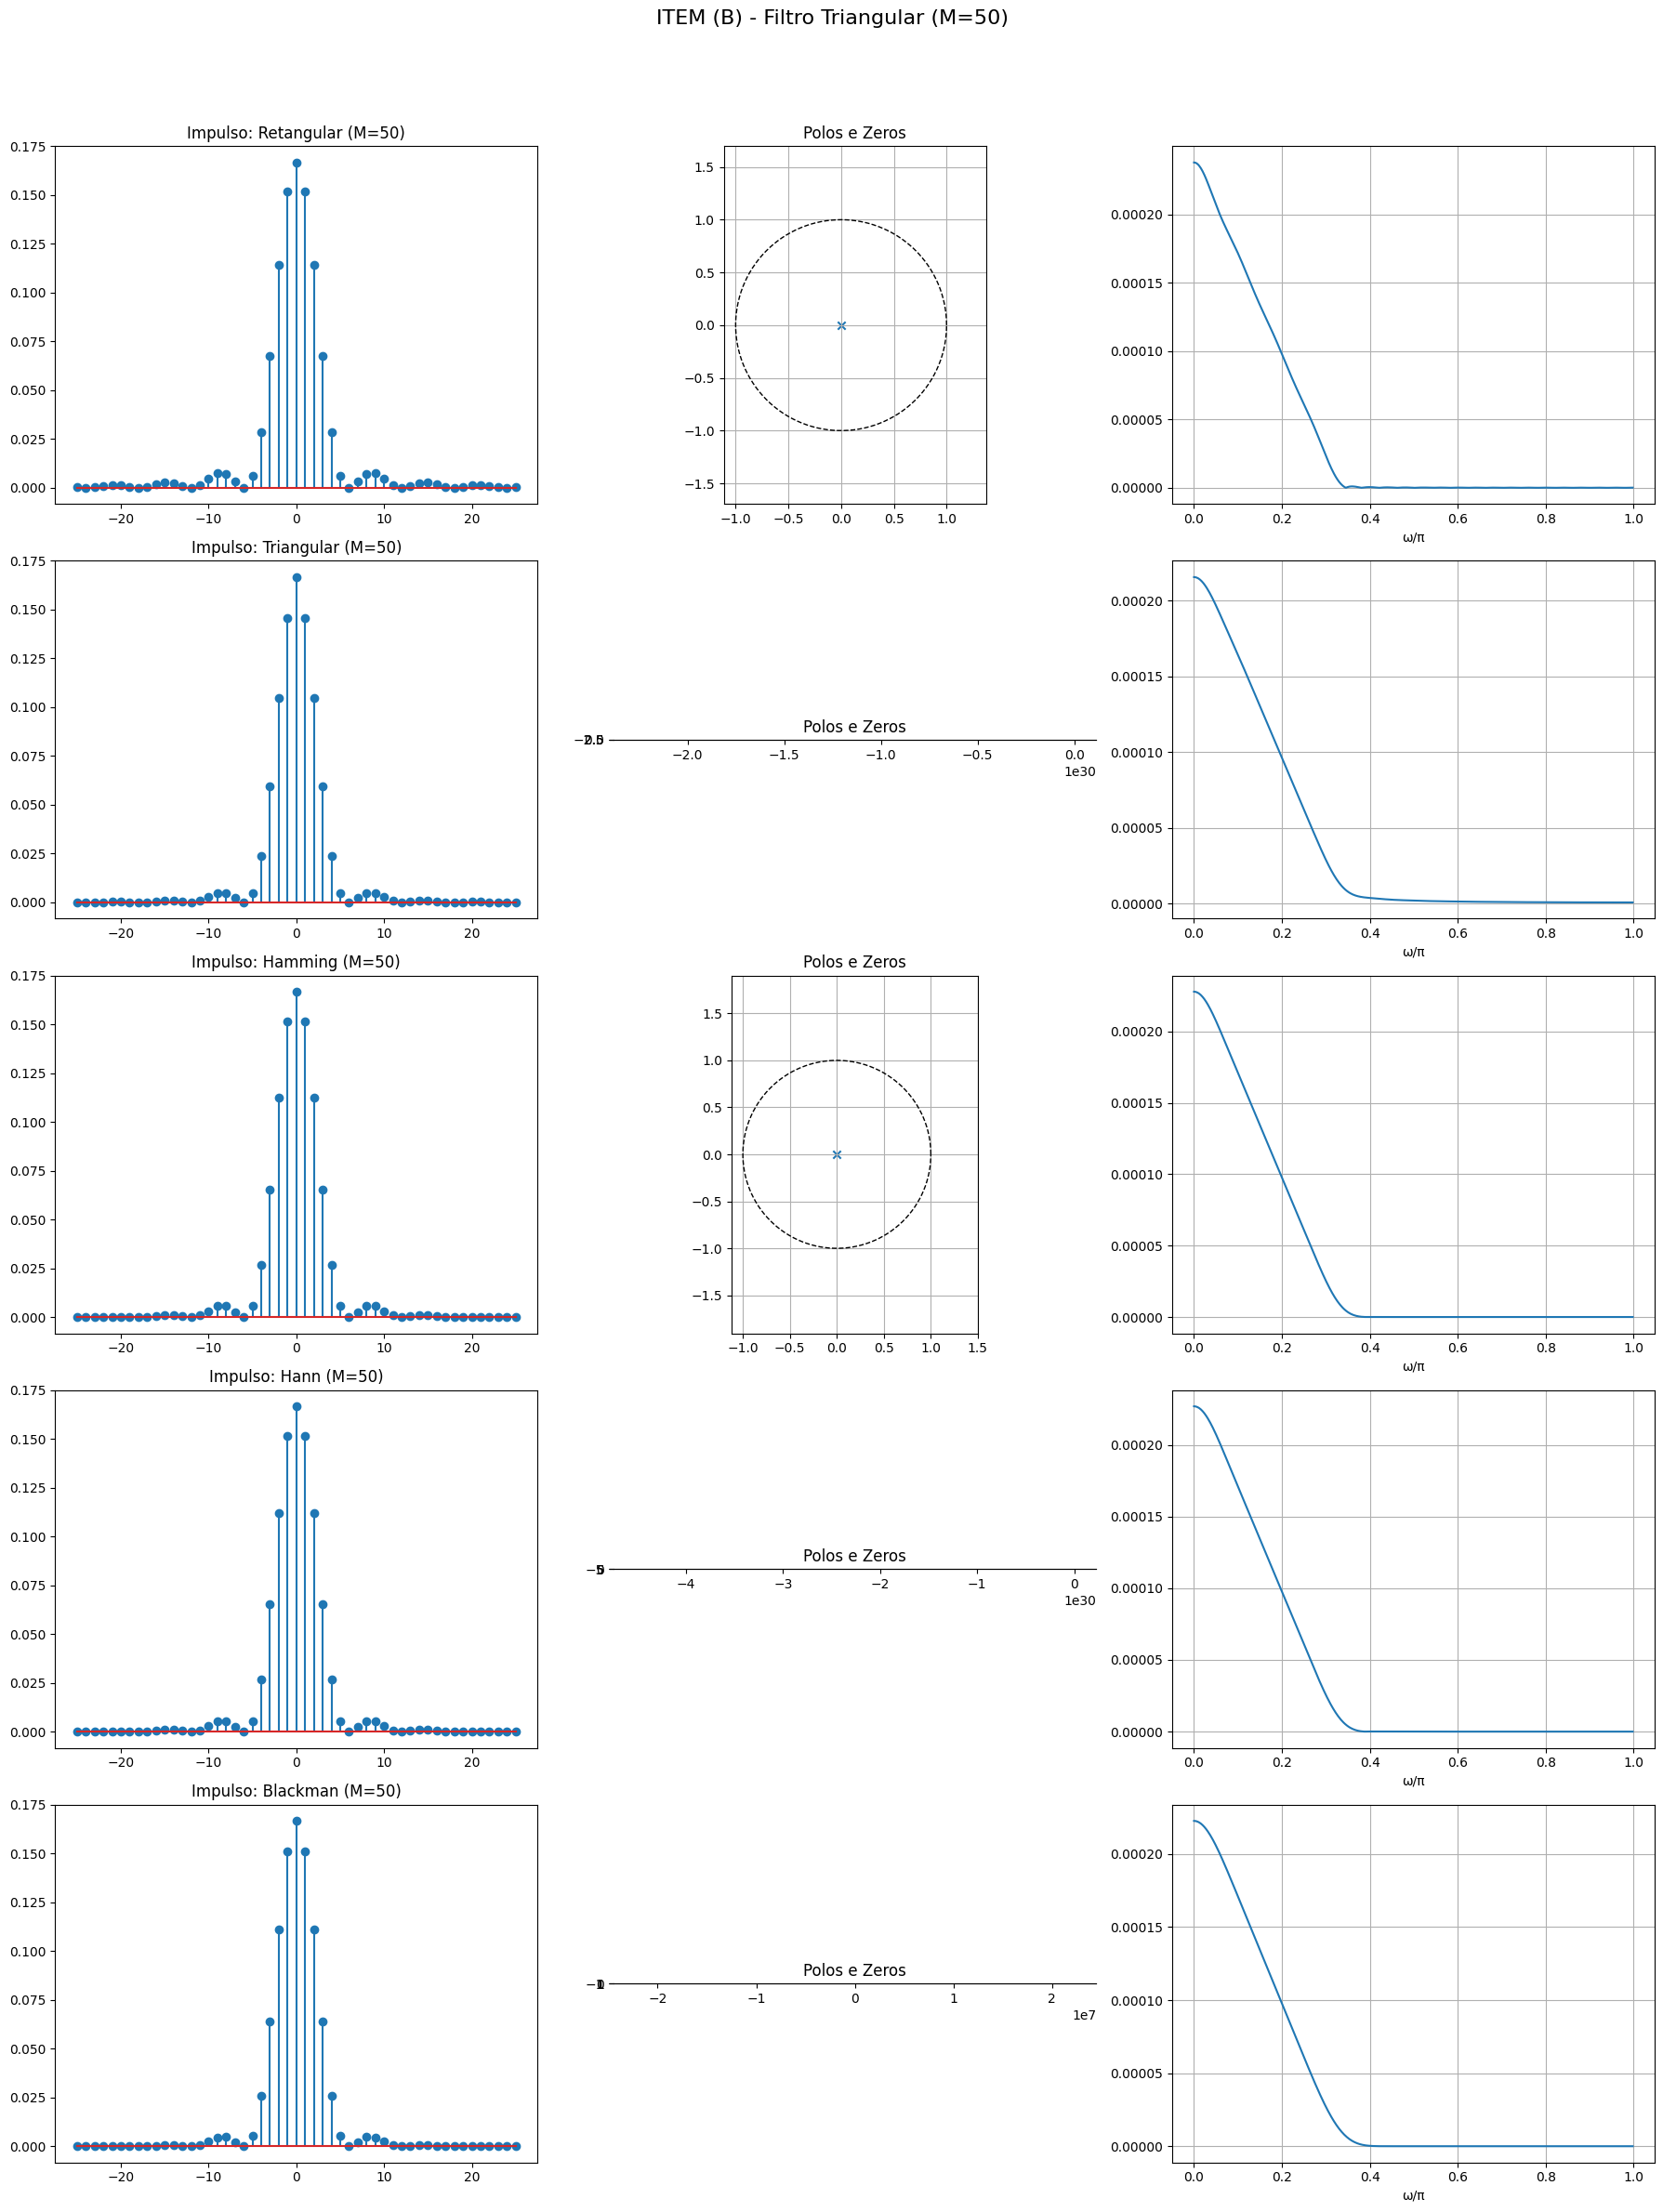

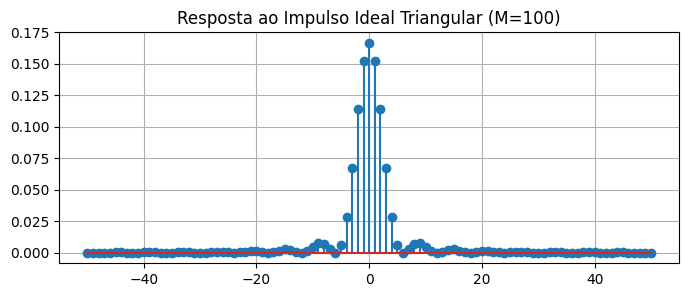

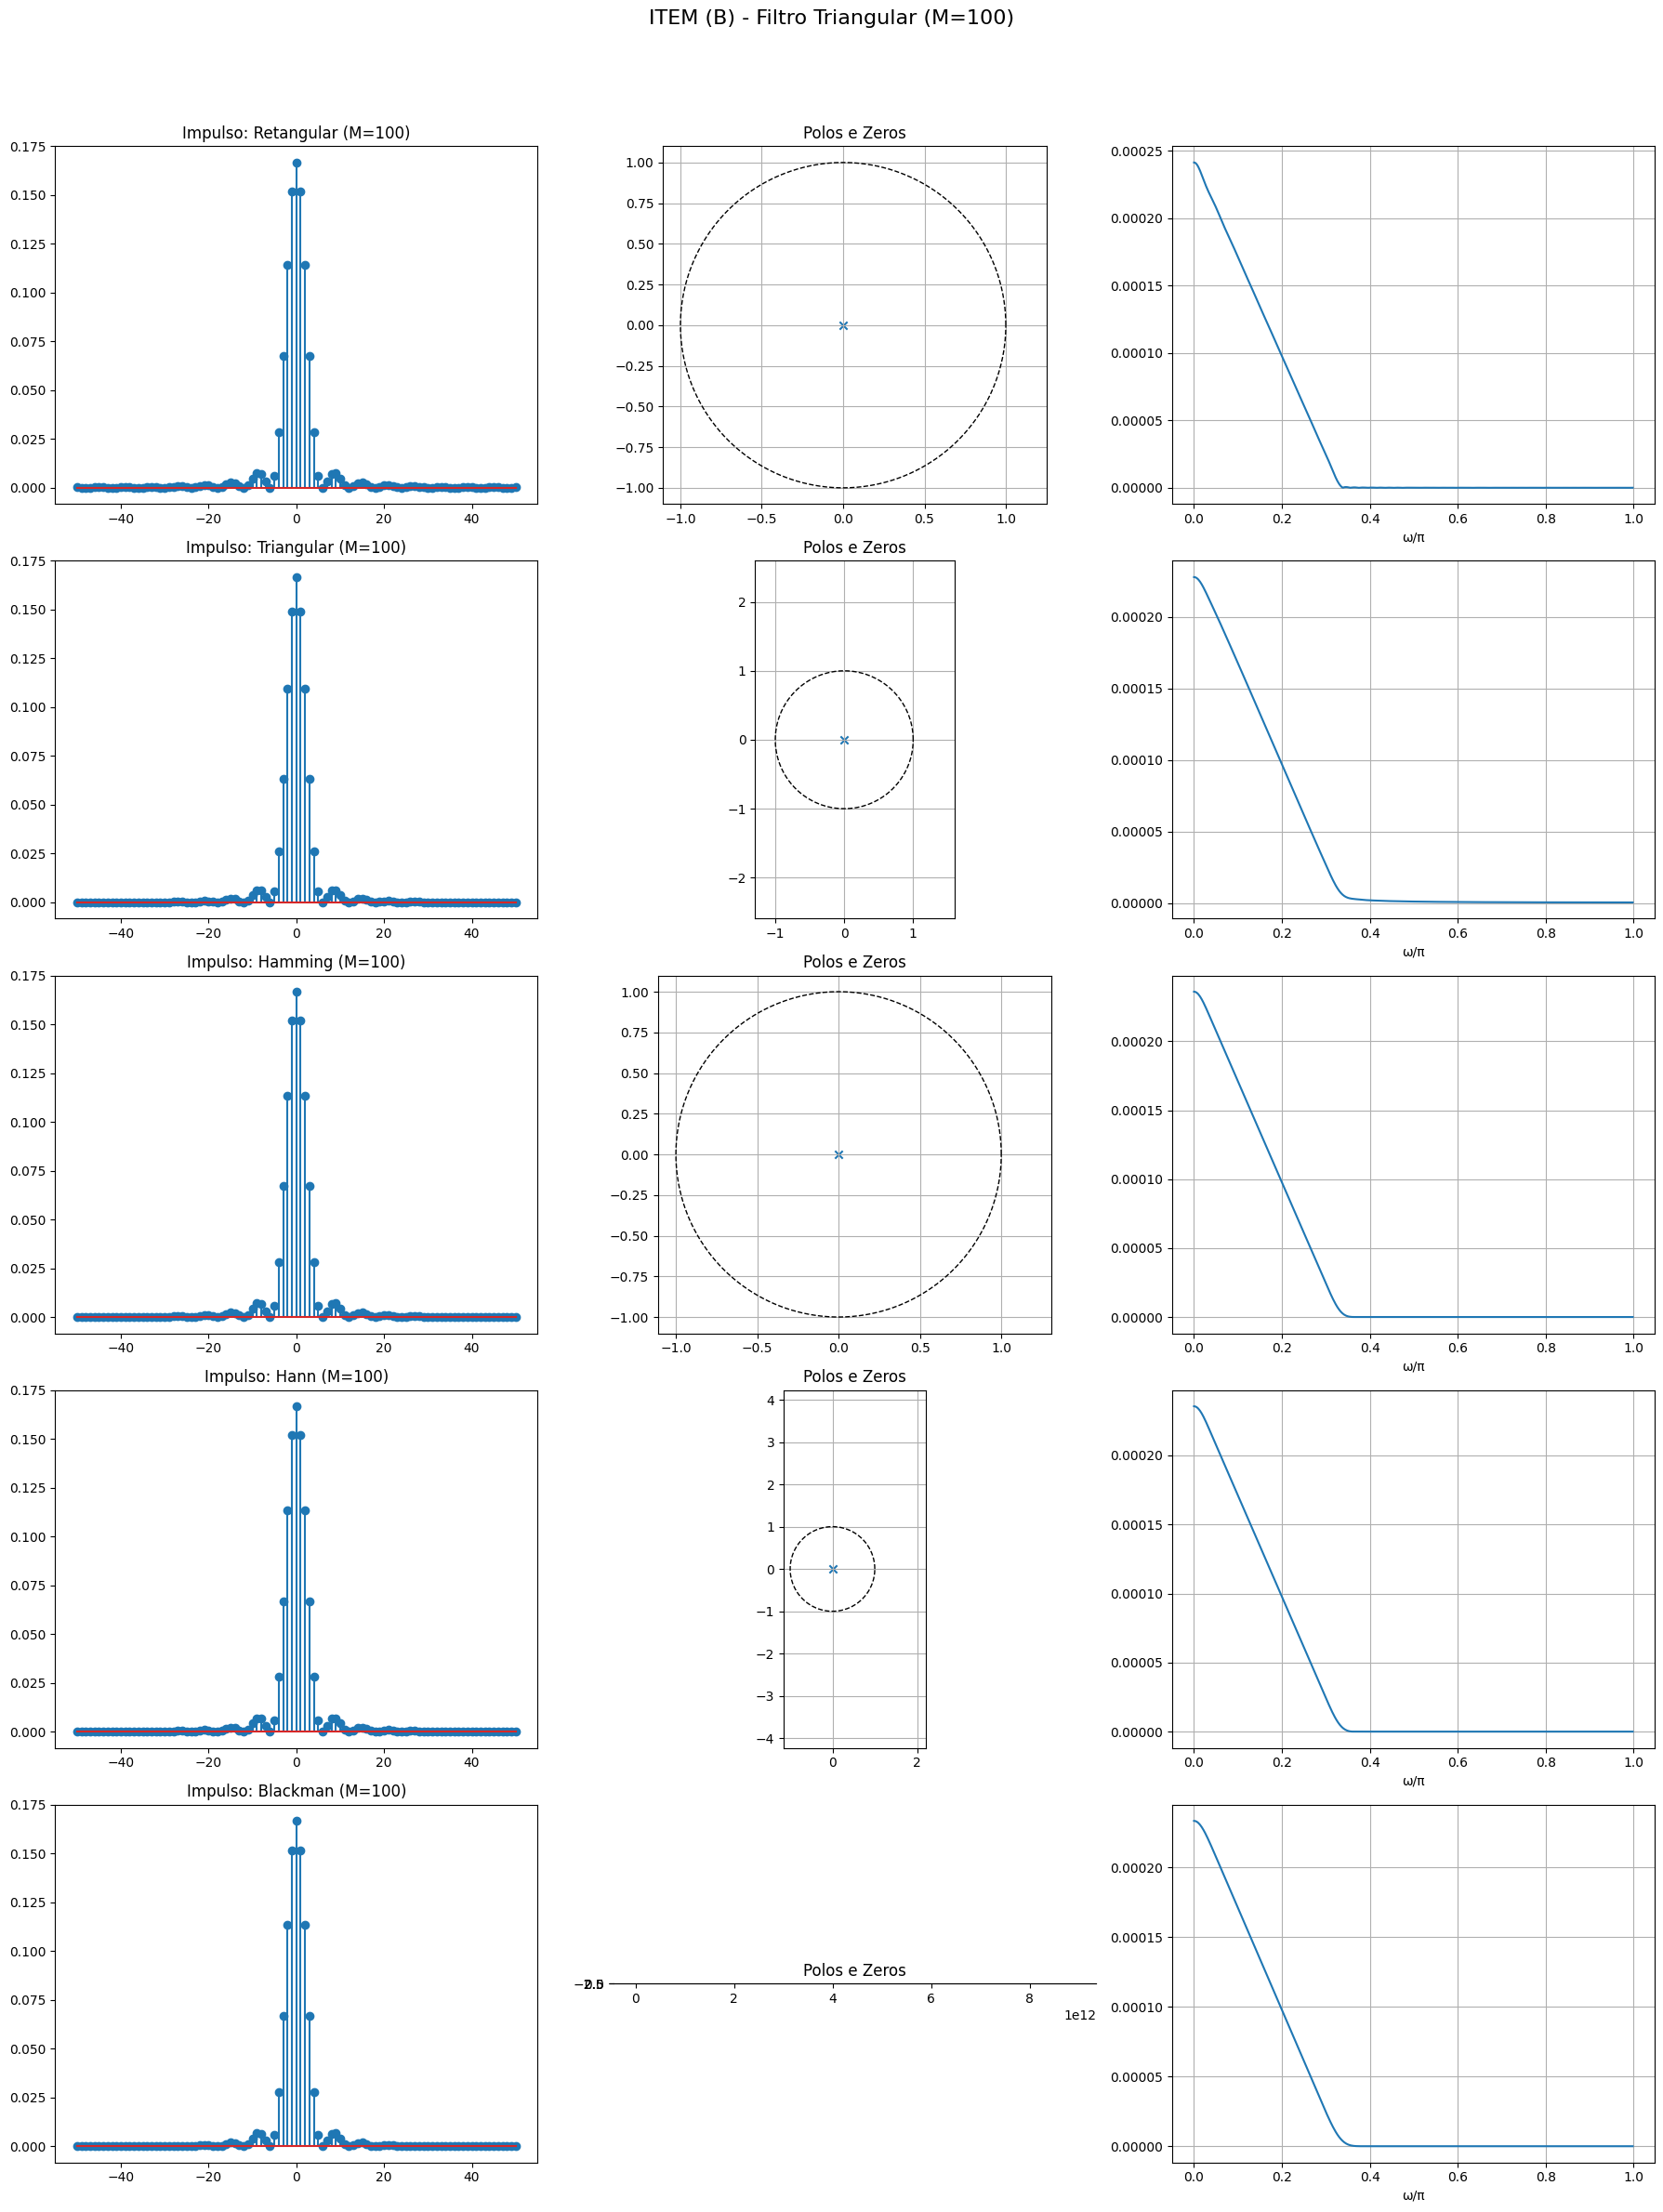

In [11]:
wc = np.pi/6

def hd_B(M):
    n = np.arange(-M//2, M//2 + 1)
    h = np.zeros(len(n))
    for i, ni in enumerate(n):
        if ni == 0:
            h[i] = wc/np.pi
        else:
            h[i] = (np.sin(wc*ni)**2) / (np.pi * wc * (ni**2))
    return n, h

for M in ORDERS:
    n, hd = hd_B(M)
    windows = {name: func(len(n)) for name, func in WINDOWS.items()}

    # Plot do Impulso Ideal Triangular (como no ref)
    plt.figure(figsize=(8, 3))
    plt.stem(n, hd)
    plt.title(f'Resposta ao Impulso Ideal Triangular (M={M})')
    plt.grid(True)
    plt.show()

    fig, axs = plt.subplots(5, 3, figsize=(18, 25))
    for idx, (win_name, w) in enumerate(windows.items()):
        h = hd * w
        axs[idx, 0].stem(n, h)
        axs[idx, 0].set_title(f'Impulso: {win_name} (M={M})')
        plot_zplane(h, axs[idx, 1])
        omega, H = freqz(h, 4096)
        axs[idx, 2].plot(omega/np.pi, np.abs(H))
        axs[idx, 2].set_xlabel('ω/π')
        axs[idx, 2].grid(True)

    plt.suptitle(f'ITEM (B) - Filtro Triangular (M={M})', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

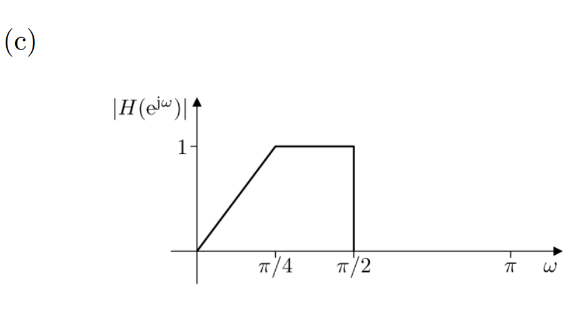

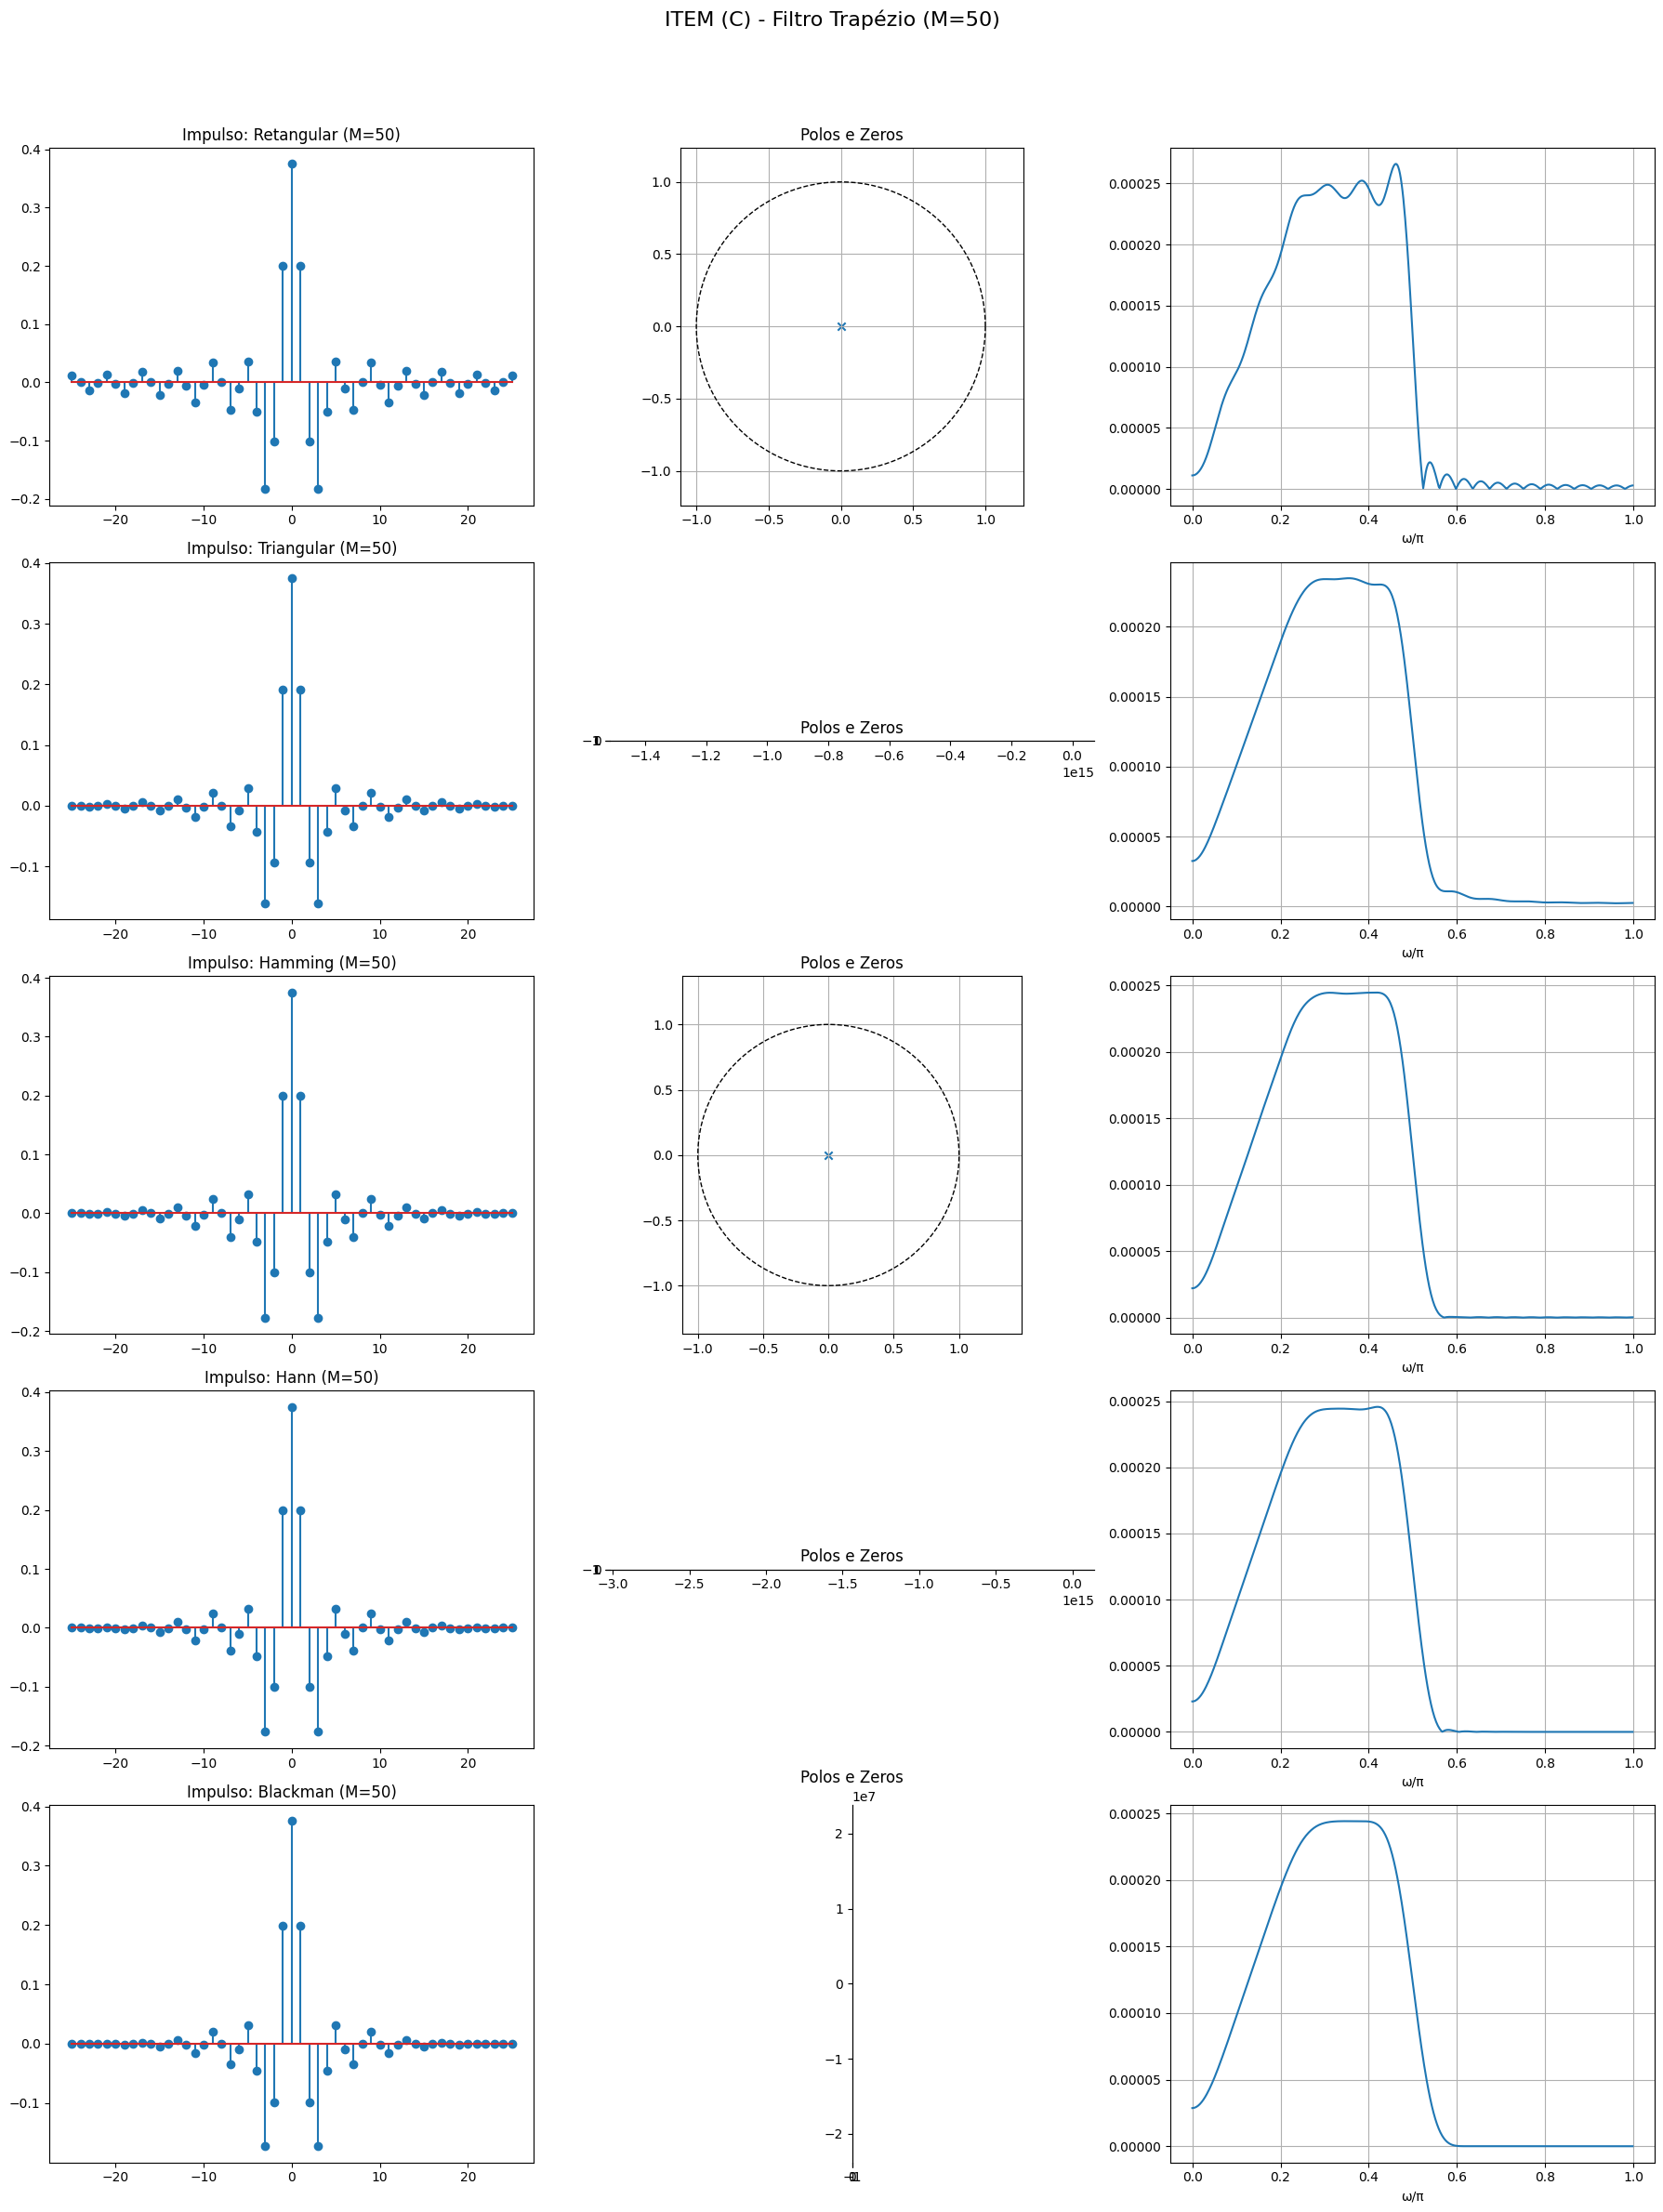

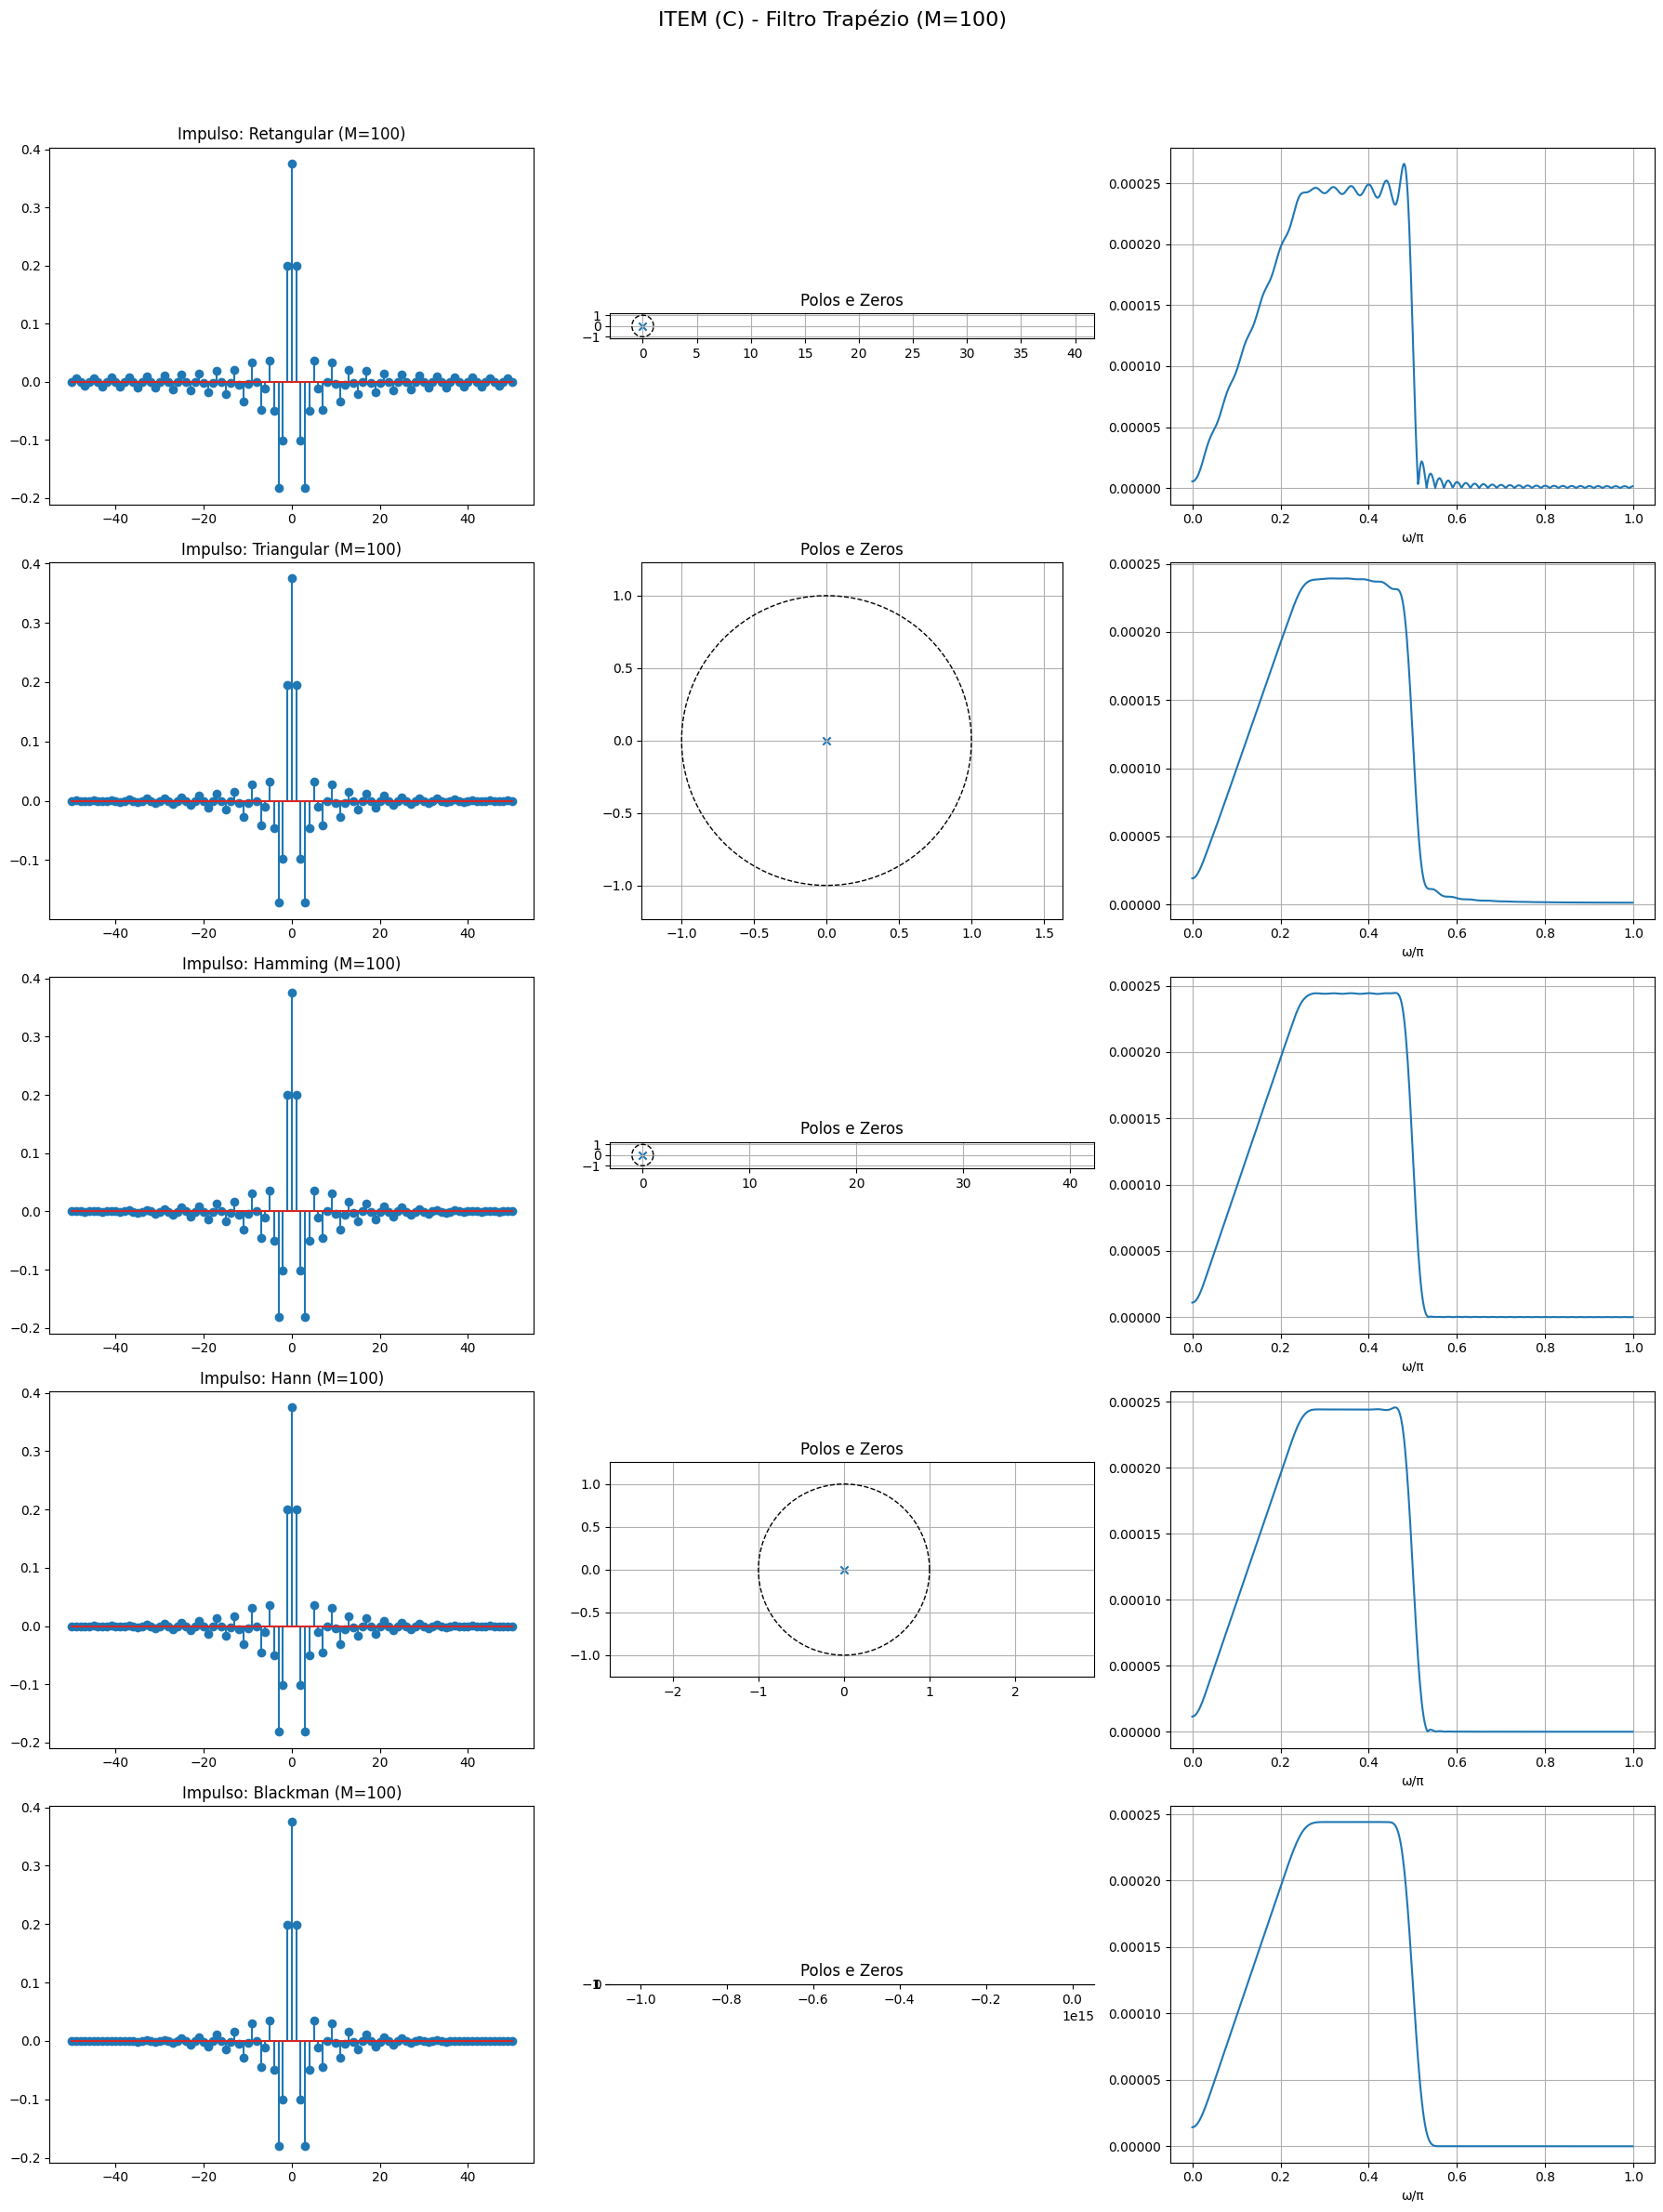

In [12]:
def hd_C(M):
    n = np.arange(-M//2, M//2 + 1)
    h = np.zeros(len(n))
    for i, ni in enumerate(n):
        if ni == 0:
            h[i] = 3/8
        else:
            h[i] = (np.sin(np.pi*ni/2)/(np.pi*ni) +
                    4*(np.cos(np.pi*ni/4)-1)/(np.pi**2 * ni**2))
    return n, h

for M in ORDERS:
    n, hd = hd_C(M)
    windows = {name: func(len(n)) for name, func in WINDOWS.items()}

    fig, axs = plt.subplots(5, 3, figsize=(18, 25))
    for idx, (win_name, w) in enumerate(windows.items()):
        h = hd * w
        axs[idx, 0].stem(n, h)
        axs[idx, 0].set_title(f'Impulso: {win_name} (M={M})')
        plot_zplane(h, axs[idx, 1])
        omega, H = freqz(h, 4096)
        axs[idx, 2].plot(omega/np.pi, np.abs(H))
        axs[idx, 2].set_xlabel('ω/π')
        axs[idx, 2].grid(True)

    plt.suptitle(f'ITEM (C) - Filtro Trapézio (M={M})', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

Ficou bem claro o compromisso prático entre a banda de transição e a atenuação das janelas: a retangular é rápida mas sofre muito com o efeito de Gibbs, a Hamming equilibra bem o jogo e a Blackman limpa muito a banda de rejeição, mesmo alargando a transição. Aumentar a ordem de M=50 para M=100 deixou o filtro bem mais seletivo (transição estreita), mas deu para ver que a atenuação dos lóbulos não muda com o M, pois é fixa de cada janela. No plano Z, todos os polos na origem ($z=0$) confirmaram que o FIR é estável e tem fase linear com atraso constante de M/2. Por fim, deu para notar como as janelas ajudam a suavizar as quinas secas das respostas ideais dos itens B e C, segurando o ripple na rampa e no topo do trapézio.